<a href="https://colab.research.google.com/github/Guru-CS/Global-Aviation-Incidents-Research/blob/main/GlobalAviationIncidentsResearch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5035 entries, 0 to 5034
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Year                   5035 non-null   int64 
 1   Quarter                5035 non-null   object
 2   Month                  5035 non-null   object
 3   Day                    5035 non-null   int64 
 4   Country/Region         4805 non-null   object
 5   Aircraft Manufacturer  5035 non-null   object
 6   Aircraft               5035 non-null   object
 7   Location               5035 non-null   object
 8   Operator               4801 non-null   object
 9   Ground                 5035 non-null   int64 
 10  Fatalities (air)       5035 non-null   int64 
 11  Aboard                 5035 non-null   int64 
dtypes: int64(5), object(7)
memory usage: 472.2+ KB


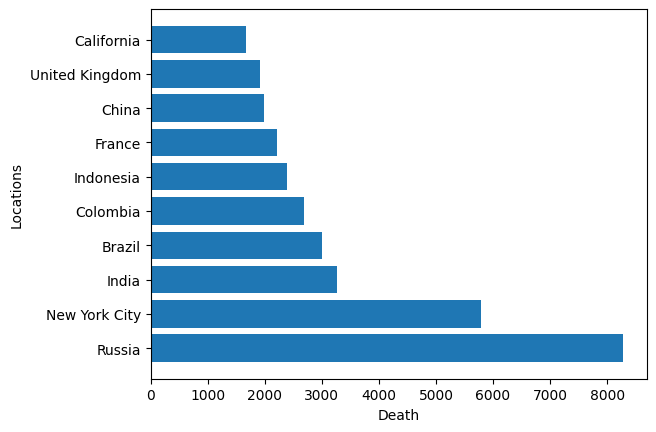

21
25
46


/tmp/ipykernel_1061/3348390338.py:147: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


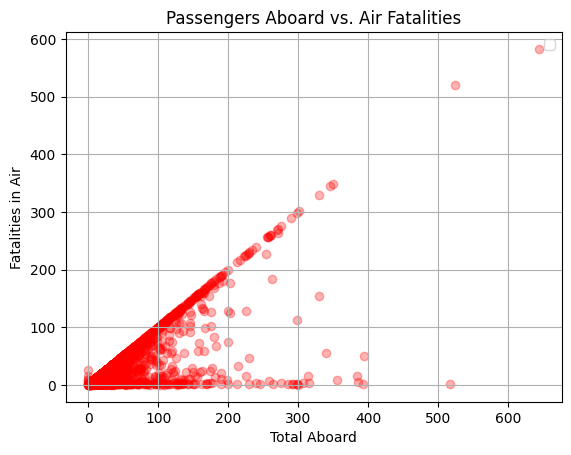

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
data= pd.read_csv("https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/Global%20Aviation%20Incidents/aircrashesFullDataUpdated_2024.csv")
data.info()
data.head()
data['Aircraft Manufacturer'] = data['Aircraft Manufacturer'].astype(str).str.strip()
data['Aircraft'] = data['Aircraft'].astype(str).str.strip()
data['Manufacturer_Grouped'] = data['Aircraft Manufacturer'].where(
    data.groupby('Aircraft Manufacturer')['Aircraft Manufacturer'].transform('count') > 15,
    'Other'
)
data['Aircraft_Grouped'] = data['Aircraft'].where(
    data.groupby('Aircraft')['Aircraft'].transform('count') > 15,
    'Other'
)
data['Aircraft_Operator'] = data['Operator'].where(
    data.groupby('Operator')['Operator'].transform('count') > 15,
    'Other'
)
# Did not type all the location mapping used AI and there are still countries i could add
location_mapping = {
    # --- U.S. States ---
    'alabama': 'Alabama',
    'alaska': 'Alaska',
    'arizona': 'Arizona',
    'arkansas': 'Arkansas',
    'california': 'California',
    'colorado': 'Colorado',
    'connecticut': 'Connecticut',
    'delaware': 'Delaware',
    'florida': 'Florida',
    'georgia': 'Georgia',
    'hawaii': 'Hawaii',
    'idaho': 'Idaho',
    'illinois': 'Illinois',
    'indiana': 'Indiana',
    'iowa': 'Iowa',
    'kansas': 'Kansas',
    'kentucky': 'Kentucky',
    'louisiana': 'Louisiana',
    'maine': 'Maine',
    'maryland': 'Maryland',
    'massachusetts': 'Massachusetts',
    'michigan': 'Michigan',
    'minnesota': 'Minnesota',
    'mississippi': 'Mississippi',
    'missouri': 'Missouri',
    'montana': 'Montana',
    'nebraska': 'Nebraska',
    'nevada': 'Nevada',
    'new hampshire': 'New Hampshire',
    'new jersey': 'New Jersey',
    'new mexico': 'New Mexico',
    'new york': 'New York City',  # Kept as New York City as in your example
    'north carolina': 'North Carolina',
    'north dakota': 'North Dakota',
    'ohio': 'Ohio',
    'oklahoma': 'Oklahoma',
    'oregon': 'Oregon',
    'pennsylvania': 'Pennsylvania',
    'rhode island': 'Rhode Island',
    'south carolina': 'South Carolina',
    'south dakota': 'South Dakota',
    'tennessee': 'Tennessee',
    'texas': 'Texas',
    'utah': 'Utah',
    'vermont': 'Vermont',
    'virginia': 'Virginia',
    'washington': 'Washington',
    'west virginia': 'West Virginia',
    'wisconsin': 'Wisconsin',
    'wyoming': 'Wyoming',
    'district of columbia': 'Washington D.C.',

    # --- Popular Countries ---
    'argentina': 'Argentina',
    'australia': 'Australia',
    'austria': 'Austria',
    'bangladesh': 'Bangladesh',
    'belgium': 'Belgium',
    'brazil': 'Brazil',
    'canada': 'Canada',
    'chile': 'Chile',
    'china': 'China',
    'colombia': 'Colombia',
    'denmark': 'Denmark',
    'egypt': 'Egypt',
    'france': 'France',
    'germany': 'Germany',
    'greece': 'Greece',
    'india': 'India',
    'indonesia': 'Indonesia',
    'ireland': 'Ireland',
    'israel': 'Israel',
    'italy': 'Italy',
    'japan': 'Japan',
    'kenya': 'Kenya',
    'mexico': 'Mexico',
    'netherlands': 'Netherlands',
    'new zealand': 'New Zealand',
    'nigeria': 'Nigeria',
    'norway': 'Norway',
    'pakistan': 'Pakistan',
    'philippines': 'Philippines',
    'poland': 'Poland',
    'portugal': 'Portugal',
    'russia': 'Russia',
    'saudi arabia': 'Saudi Arabia',
    'singapore': 'Singapore',
    'south africa': 'South Africa',
    'south korea': 'South Korea',
    'spain': 'Spain',
    'sweden': 'Sweden',
    'switzerland': 'Switzerland',
    'thailand': 'Thailand',
    'turkey': 'Turkey',
    'ukraine': 'Ukraine',
    'united arab emirates': 'United Arab Emirates',
    'uae': 'United Arab Emirates',
    'united kingdom': 'United Kingdom',
    'uk': 'United Kingdom',
    'london': 'London',
    'united states': 'United States',
    'usa': 'United States',
    'vietnam': 'Vietnam'
}
for keyword, clean_name in location_mapping.items():
    mask = data['Location'].str.contains(keyword, case=False, na=False)
    data.loc[mask, 'Location'] = clean_name
filtered_df=data.drop_duplicates()
filtered_df = filtered_df[(filtered_df['Fatalities (air)']>0)|(filtered_df['Ground']>0)]
filtered_df["Total Fatalities"]=filtered_df['Fatalities (air)'] + filtered_df['Ground']
plt.xlabel("Death")
plt.ylabel("Locations")
top_locations = (filtered_df.groupby("Location")["Total Fatalities"].sum().sort_values(ascending=False).head(10))
plt.barh(top_locations.index, top_locations.values)
plt.show()
print(filtered_df['Aircraft_Grouped'].nunique())
print(filtered_df['Aircraft_Operator'].nunique())
print(filtered_df['Manufacturer_Grouped'].nunique())
filtered_df.head(50)
plt.scatter(filtered_df['Aboard'], filtered_df['Fatalities (air)'], alpha=0.3, color='red')
plt.title('Passengers Aboard vs. Air Fatalities')
plt.xlabel('Total Aboard')
plt.ylabel('Fatalities in Air')
plt.legend()
plt.grid(True)
plt.show()
